In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("CTG DATA CLUSTERING PIPELINE (No PCA)")
print("=" * 80)
df=pd.read_excel('CTG.xls',sheet_name=1)

CTG DATA CLUSTERING PIPELINE (No PCA)


In [2]:
df['Unnamed: 9'].isnull().sum()

2130

In [3]:
print(df.columns.tolist())

['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 22, 'Unnamed: 44', 23]


In [4]:
# Fix headers
df.columns = df.iloc[0]
df = df.iloc[1:]
df = df.reset_index(drop=True)

empty_cols = ['Unnamed: 9', 'Unnamed: 42', 'Unnamed: 44']

df = df.drop(columns=empty_cols, errors='ignore')

# Remove summary row
df = df.iloc[:-1]

print("Shape after cleaning:", df.shape)

Shape after cleaning: (2128, 46)


In [5]:
# df=pd.read_excel('CTG.xls',sheet_name='Raw Data')

In [6]:
# Define features and target - ONLY these 21 columns
feature_cols = ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 
                'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 
                'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency']

target_col = 'NSP'

# Extract only the feature columns we want
available_features = [col for col in feature_cols if col in df.columns]
print(f"   Available features: {len(available_features)}/{len(feature_cols)}")

X = df[available_features].copy()
y_raw = df[target_col].copy()

print(f"   Features: {len(available_features)}")



   Available features: 21/21
   Features: 21


In [7]:
#:Handle NaN in y
print(f"\n   Checking target variable (NSP):")
print(f"     Original shape: {y_raw.shape}")
print(f"     NaN count in y: {y_raw.isna().sum()}")

# Remove rows where y is NaN
valid_mask = ~y_raw.isna()
X = X[valid_mask].copy()
y = y_raw[valid_mask].copy()

print(f"     After removing NaN: {len(y)} samples")

# Convert y to integer type
y = y.astype(int)

print(f"     Target classes: {np.unique(y)} (1=Normal, 2=Suspicious, 3=Pathological)")

# Target distribution
print(f"\n   Target Distribution (NSP - Fetal Health):")
class_counts = y.value_counts().sort_index()
for cls, count in class_counts.items():
    class_name = {1: 'Normal', 2: 'Suspicious', 3: 'Pathological'}.get(cls, 'Unknown')
    print(f"     Class {cls} ({class_name}): {count} samples ({count/len(y)*100:.1f}%)")


   Checking target variable (NSP):
     Original shape: (2128,)
     NaN count in y: 2
     After removing NaN: 2126 samples
     Target classes: [1 2 3] (1=Normal, 2=Suspicious, 3=Pathological)

   Target Distribution (NSP - Fetal Health):
     Class 1 (Normal): 1655 samples (77.8%)
     Class 2 (Suspicious): 295 samples (13.9%)
     Class 3 (Pathological): 176 samples (8.3%)


In [8]:
# Check missing values in X
missing_counts = X.isnull().sum()
total_missing = missing_counts.sum()
print(f"\n   Missing values in features: {total_missing}")
if total_missing > 0:
    print(f"   Features with missing values:\n{missing_counts[missing_counts > 0]}")

# Handle missing values with median imputation
print("\n[2] Handling missing values...")
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
print(f"   Missing values after imputation: {X_imputed.isnull().sum().sum()}")


   Missing values in features: 0

[2] Handling missing values...
   Missing values after imputation: 0


In [9]:
# Feature scaling (StandardScaler - critical for distance-based algorithms)

print("\n[3] Feature scaling...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(f"   Scaled data shape: {X_scaled_df.shape}")
print(f"   Mean after scaling: {X_scaled_df.mean().mean():.2e}")
print(f"   Std after scaling: {X_scaled_df.std().mean():.2f}")


[3] Feature scaling...
   Scaled data shape: (2126, 27)
   Mean after scaling: -1.21e-18
   Std after scaling: 1.00


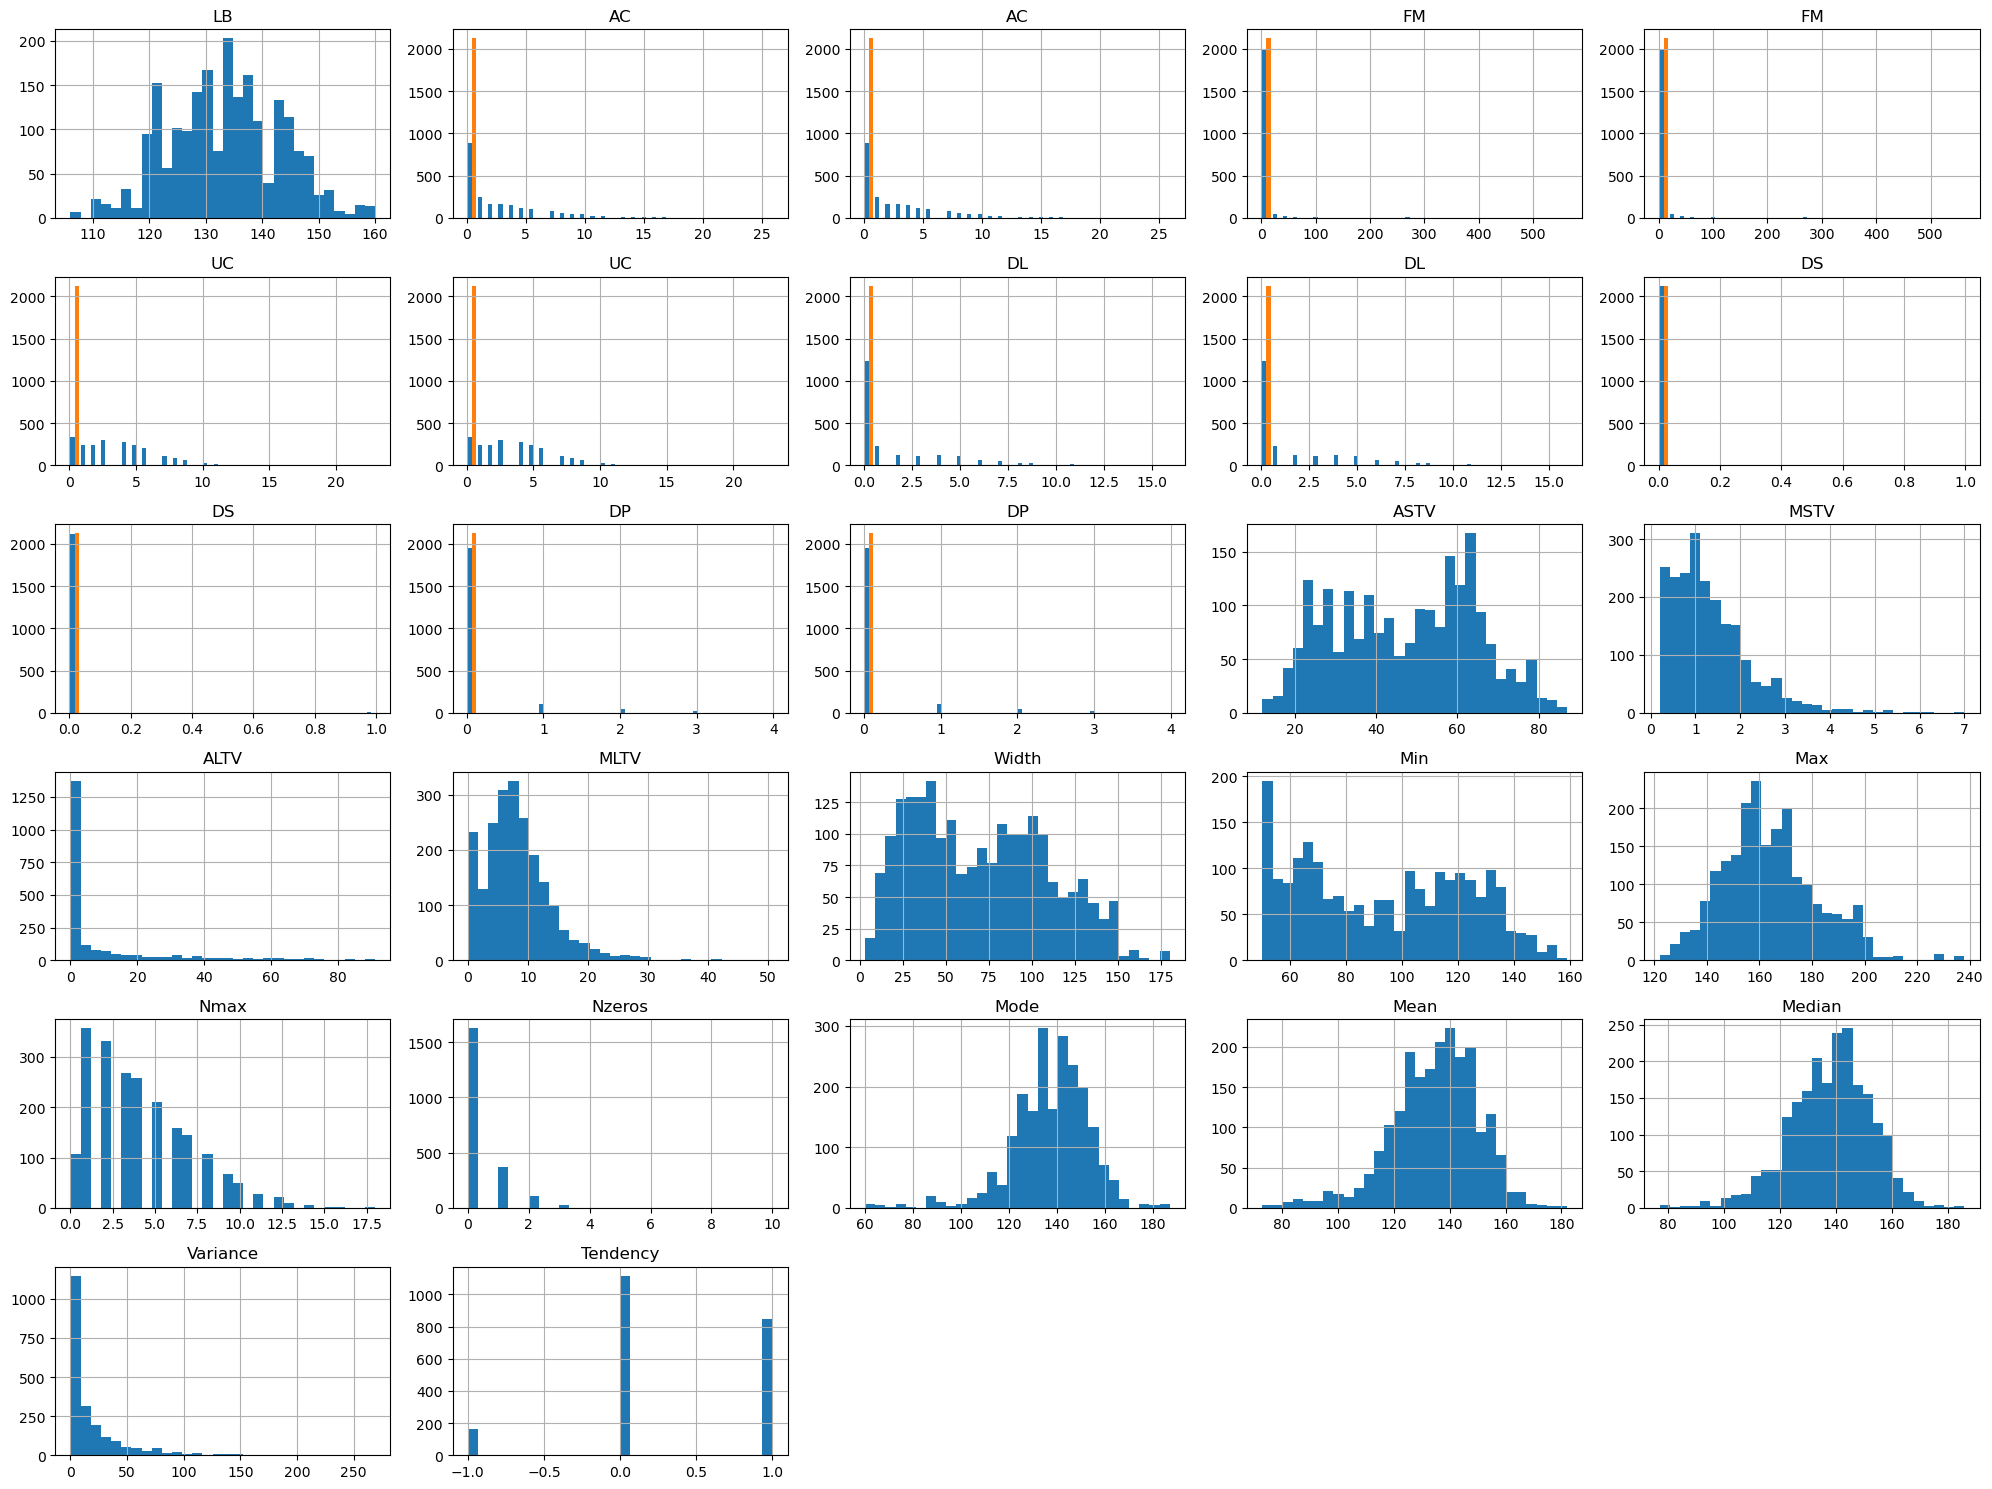

In [10]:
# Exploratory Data Analysis

# Feature distributions (histograms)

import matplotlib.pyplot as plt

X_imputed.hist(figsize=(20, 15), bins=30)
plt.tight_layout()
plt.show()

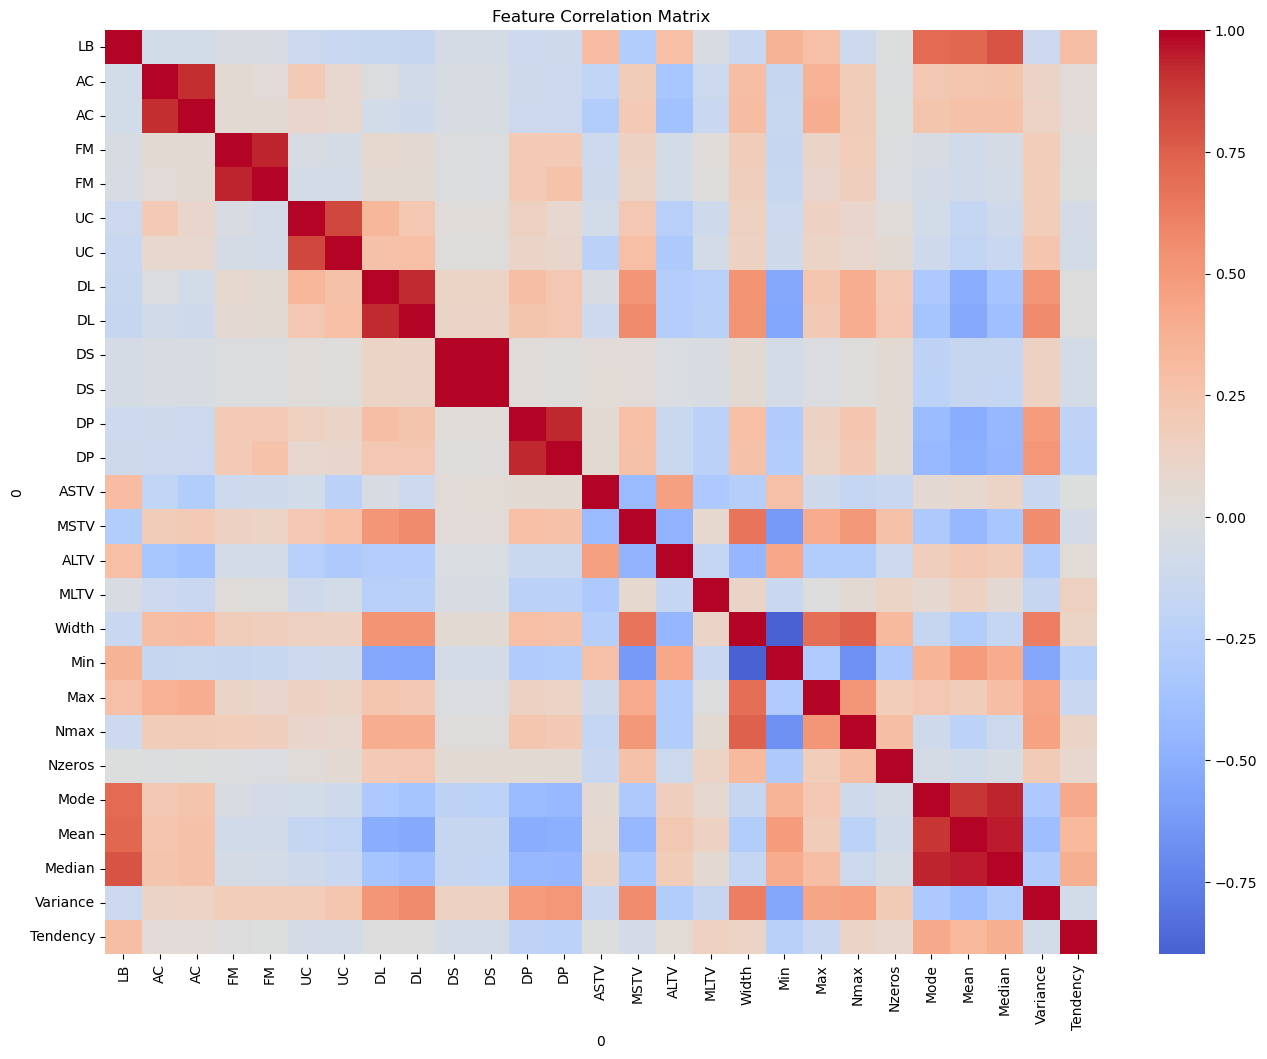

In [11]:
# Correlation heatmap

plt.figure(figsize=(16, 12))
sns.heatmap(X_imputed.corr(), cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

In [12]:
# Skewness analysis

print("\nSkewness Analysis:")
skew_results = []
for col in available_features:
    data_values = X_imputed[col].values.flatten()
    skew_val = pd.Series(data_values).skew()
    skew_val = float(skew_val)
    
    if abs(skew_val) < 0.5:
        interpretation = "Approximately symmetric"
    elif abs(skew_val) < 1:
        interpretation = "Moderately skewed"
    else:
        interpretation = "Highly skewed"
    direction = "Right-skewed" if skew_val > 0 else "Left-skewed"
    skew_results.append({'Feature': col, 'Skewness': skew_val, 'Direction': direction, 'Interpretation': interpretation})

skew_df = pd.DataFrame(skew_results)
skew_df = skew_df.sort_values('Skewness', key=lambda x: abs(x), ascending=False)
print(skew_df.to_string(index=False))



Skewness Analysis:
 Feature  Skewness    Direction          Interpretation
      DS 24.593795 Right-skewed           Highly skewed
      FM 13.359059 Right-skewed           Highly skewed
      DP  6.217712 Right-skewed           Highly skewed
  Nzeros  3.920287 Right-skewed           Highly skewed
Variance  3.219974 Right-skewed           Highly skewed
      DL  2.980882 Right-skewed           Highly skewed
      AC  2.701460 Right-skewed           Highly skewed
    ALTV  2.195075 Right-skewed           Highly skewed
    MSTV  1.657339 Right-skewed           Highly skewed
      UC  1.584827 Right-skewed           Highly skewed
    MLTV  1.331998 Right-skewed           Highly skewed
    Mode -0.995178  Left-skewed       Moderately skewed
    Nmax  0.892886 Right-skewed       Moderately skewed
    Mean -0.651019  Left-skewed       Moderately skewed
     Max  0.577862 Right-skewed       Moderately skewed
  Median -0.478414  Left-skewed Approximately symmetric
   Width  0.314235 Right-ske

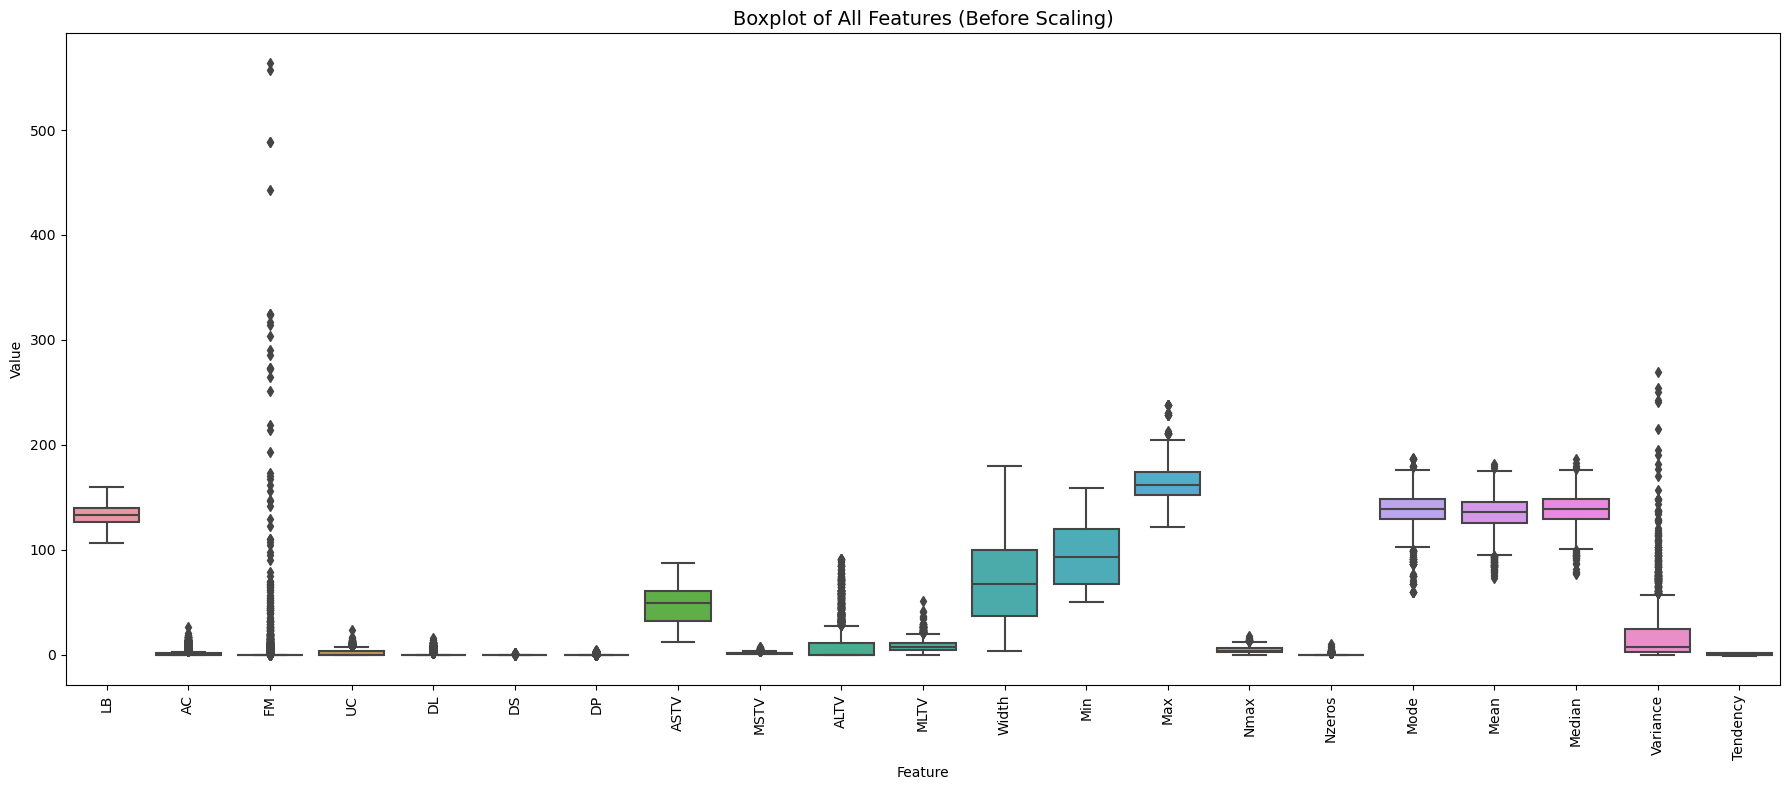

In [13]:
plt.figure(figsize=(18, 8))
X_melted = X_imputed.melt(var_name='Feature', value_name='Value')
sns.boxplot(data=X_melted, x='Feature', y='Value')
plt.xticks(rotation=90)
plt.title('Boxplot of All Features (Before Scaling)', fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
# Import clustering libraries
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (silhouette_score, adjusted_rand_score, 
                             normalized_mutual_info_score, davies_bouldin_score,
                             calinski_harabasz_score)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("MODEL SELECTION & TRAINING (No PCA)")
print("=" * 60)
print(f"\nData shape: {X_scaled.shape}")
print(f"Target shape: {y.shape}")
print(f"Target classes: {np.unique(y)} (1=Normal, 2=Suspicious, 3=Pathological)")

MODEL SELECTION & TRAINING (No PCA)

Data shape: (2126, 27)
Target shape: (2126,)
Target classes: [1 2 3] (1=Normal, 2=Suspicious, 3=Pathological)


### K-MEANS - Hyperparameter Tuning (Elbow Method + Silhouette)

**Hyperparameters to tune:** n_clusters (k)

**Methods:**
- **Elbow Method:** Plot inertia (within-cluster sum of squares) vs. k. Optimal k is at the "elbow" where inertia decrease slows.
- **Silhouette Score:** Measures cluster cohesion and separation. Higher is better (max 1).

We test k values from 2 to 10 and select the best based on silhouette score.

K-MEANS: Hyperparameter Tuning (Finding optimal k)
   k=2: Inertia=47600, Silhouette=0.2335
   k=3: Inertia=42440, Silhouette=0.1727
   k=4: Inertia=38997, Silhouette=0.1370
   k=5: Inertia=34769, Silhouette=0.1445
   k=6: Inertia=31782, Silhouette=0.1573
   k=7: Inertia=28745, Silhouette=0.1692
   k=8: Inertia=27228, Silhouette=0.1520
   k=9: Inertia=25859, Silhouette=0.1547
   k=10: Inertia=24943, Silhouette=0.1569


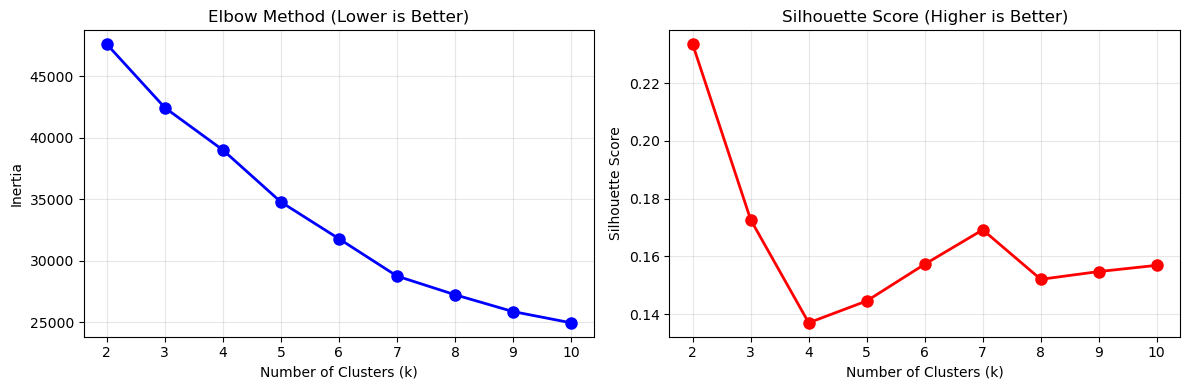


✓ Optimal k from silhouette: 2
  True number of classes: 3
  Note: Using k=3 for fair comparison with true labels


In [15]:
# Cell 2: K-MEANS - Find optimal k
print("=" * 60)
print("K-MEANS: Hyperparameter Tuning (Finding optimal k)")
print("=" * 60)

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    inertias.append(kmeans_temp.inertia_)
    sil_score = silhouette_score(X_scaled, labels_temp)
    silhouette_scores.append(sil_score)
    print(f"   k={k}: Inertia={kmeans_temp.inertia_:.0f}, Silhouette={sil_score:.4f}")

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method (Lower is Better)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (Higher is Better)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\n✓ Optimal k from silhouette: {optimal_k}")
print(f"  True number of classes: 3")
print(f"  Note: Using k=3 for fair comparison with true labels")

### K-MEANS - Train with Optimal k and Evaluate

We train K-Means with k=3 (matching true classes) and evaluate using multiple metrics.

**Evaluation Metrics:**
- **Silhouette Score (Internal):** Measures cluster separation (-1 to 1, higher = better)
- **Davies-Bouldin Index (Internal):** Average similarity between clusters (lower = better)
- **Calinski-Harabasz Index (Internal):** Ratio of between-cluster to within-cluster variance (higher = better)
- **Adjusted Rand Index (External):** Agreement with true labels (1 = perfect)
- **Normalized Mutual Info (External):** Information shared with true labels (1 = perfect)

In [16]:
# Cell 3: K-MEANS - Train and Evaluate
print("\n" + "=" * 60)
print("K-MEANS: Training and Evaluation (k=3)")
print("=" * 60)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Internal metrics
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_davies = davies_bouldin_score(X_scaled, kmeans_labels)
kmeans_calinski = calinski_harabasz_score(X_scaled, kmeans_labels)

# External metrics
kmeans_ari = adjusted_rand_score(y, kmeans_labels)
kmeans_nmi = normalized_mutual_info_score(y, kmeans_labels)

print(f"\n📊 K-MEANS EVALUATION (k=3):")
print("-" * 40)
print("INTERNAL METRICS (unsupervised):")
print(f"   Silhouette Score: {kmeans_silhouette:.4f} (higher = better)")
print(f"   Davies-Bouldin Index: {kmeans_davies:.4f} (lower = better)")
print(f"   Calinski-Harabasz Index: {kmeans_calinski:.2f} (higher = better)")
print("-" * 40)
print("EXTERNAL METRICS (supervised validation):")
print(f"   Adjusted Rand Index: {kmeans_ari:.4f} (1 = perfect)")
print(f"   Normalized Mutual Info: {kmeans_nmi:.4f} (1 = perfect)")

print(f"\n   Cluster sizes:")
for i in range(3):
    size = np.sum(kmeans_labels == i)
    print(f"     Cluster {i}: {size} samples ({size/len(kmeans_labels)*100:.1f}%)")


K-MEANS: Training and Evaluation (k=3)

📊 K-MEANS EVALUATION (k=3):
----------------------------------------
INTERNAL METRICS (unsupervised):
   Silhouette Score: 0.1727 (higher = better)
   Davies-Bouldin Index: 1.9131 (lower = better)
   Calinski-Harabasz Index: 374.22 (higher = better)
----------------------------------------
EXTERNAL METRICS (supervised validation):
   Adjusted Rand Index: 0.1231 (1 = perfect)
   Normalized Mutual Info: 0.1991 (1 = perfect)

   Cluster sizes:
     Cluster 0: 1056 samples (49.7%)
     Cluster 1: 167 samples (7.9%)
     Cluster 2: 903 samples (42.5%)


### Cell 4: HIERARCHICAL - Hyperparameter Tuning (Linkage Methods)

**Hyperparameter to tune:** linkage method

**Methods tested:**
- **ward:** Minimizes variance within clusters (default)
- **complete:** Uses maximum distance between clusters
- **average:** Uses average distance between clusters

We test all three and select the one with highest silhouette score.

In [17]:
# Cell 4: HIERARCHICAL - Test linkage methods
print("=" * 60)
print("HIERARCHICAL: Hyperparameter Tuning (Linkage Methods)")
print("=" * 60)

linkage_methods = ['ward', 'complete', 'average']
hier_sil_scores = {}

print("Testing linkage methods (k=3):")
for linkage_method in linkage_methods:
    hierarchical_temp = AgglomerativeClustering(n_clusters=3, linkage=linkage_method)
    hier_labels_temp = hierarchical_temp.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, hier_labels_temp)
    ari_score = adjusted_rand_score(y, hier_labels_temp)
    
    hier_sil_scores[linkage_method] = sil_score
    print(f"   {linkage_method}: Silhouette={sil_score:.4f}, ARI={ari_score:.4f}")

best_linkage = max(hier_sil_scores, key=hier_sil_scores.get)
print(f"\n✓ Best linkage method: {best_linkage}")

HIERARCHICAL: Hyperparameter Tuning (Linkage Methods)
Testing linkage methods (k=3):
   ward: Silhouette=0.1227, ARI=0.3487
   complete: Silhouette=0.5553, ARI=0.0469
   average: Silhouette=0.5553, ARI=0.0469

✓ Best linkage method: complete


### Cell 5: HIERARCHICAL - Train with Best Linkage and Evaluate

We train hierarchical clustering using the best linkage method (complete) and evaluate all metrics.

In [18]:
# Cell 5: HIERARCHICAL - Train and Evaluate
print("\n" + "=" * 60)
print("HIERARCHICAL: Training and Evaluation")
print("=" * 60)

hierarchical = AgglomerativeClustering(n_clusters=3, linkage=best_linkage)
hier_labels = hierarchical.fit_predict(X_scaled)

# Internal metrics
hier_silhouette = silhouette_score(X_scaled, hier_labels)
hier_davies = davies_bouldin_score(X_scaled, hier_labels)
hier_calinski = calinski_harabasz_score(X_scaled, hier_labels)

# External metrics
hier_ari = adjusted_rand_score(y, hier_labels)
hier_nmi = normalized_mutual_info_score(y, hier_labels)

print(f"\n📊 HIERARCHICAL EVALUATION (k=3, linkage={best_linkage}):")
print("-" * 40)
print("INTERNAL METRICS:")
print(f"   Silhouette Score: {hier_silhouette:.4f}")
print(f"   Davies-Bouldin Index: {hier_davies:.4f}")
print(f"   Calinski-Harabasz Index: {hier_calinski:.2f}")
print("-" * 40)
print("EXTERNAL METRICS:")
print(f"   Adjusted Rand Index: {hier_ari:.4f}")
print(f"   Normalized Mutual Info: {hier_nmi:.4f}")

print(f"\n   Cluster sizes:")
for i in range(3):
    size = np.sum(hier_labels == i)
    print(f"     Cluster {i}: {size} samples ({size/len(hier_labels)*100:.1f}%)")


HIERARCHICAL: Training and Evaluation

📊 HIERARCHICAL EVALUATION (k=3, linkage=complete):
----------------------------------------
INTERNAL METRICS:
   Silhouette Score: 0.5553
   Davies-Bouldin Index: 0.6762
   Calinski-Harabasz Index: 187.65
----------------------------------------
EXTERNAL METRICS:
   Adjusted Rand Index: 0.0469
   Normalized Mutual Info: 0.0318

   Cluster sizes:
     Cluster 0: 2092 samples (98.4%)
     Cluster 1: 7 samples (0.3%)
     Cluster 2: 27 samples (1.3%)


### Cell 6: DBSCAN - Hyperparameter Tuning (Grid Search)

**Hyperparameters to tune:**
- **eps:** Neighborhood radius (smaller = more clusters, more noise)
- **min_samples:** Minimum points to form a dense region

**Method:** Grid search over eps (0.8 to 2.4) and min_samples (3 to 15)
**Selection criteria:** Best silhouette score among configurations with ≥2 clusters

**k-Distance Graph Concept:** The optimal eps is often at the "knee" of the sorted distances to k-th nearest neighbor. Our grid search approximates this.

In [19]:
# Cell 6: DBSCAN - Parameter tuning
print("=" * 60)
print("DBSCAN: Hyperparameter Tuning (Grid Search)")
print("=" * 60)

eps_values = np.arange(0.8, 2.5, 0.2)
min_samples_values = [3, 5, 7, 10, 15]

dbscan_results = []
best_sil = -1
best_params = None

print("Testing combinations of eps and min_samples:")
print("-" * 65)
print(f"{'eps':<6} {'min_samples':<12} {'Clusters':<10} {'Noise':<8} {'Silhouette':<10}")
print("-" * 65)

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan_temp = DBSCAN(eps=eps, min_samples=min_samples)
        labels_temp = dbscan_temp.fit_predict(X_scaled)
        
        n_clusters = len(set(labels_temp)) - (1 if -1 in labels_temp else 0)
        n_noise = np.sum(labels_temp == -1)
        
        if n_clusters >= 2:
            mask = labels_temp != -1
            if mask.sum() >= 2:
                sil_score = silhouette_score(X_scaled[mask], labels_temp[mask])
                if sil_score > best_sil:
                    best_sil = sil_score
                    best_params = (eps, min_samples, n_clusters, n_noise)
        else:
            sil_score = -1
        
        print(f"{eps:<6.1f} {min_samples:<12} {n_clusters:<10} {n_noise:<8} {sil_score:<10.4f}")

print(f"\n✓ Best DBSCAN parameters:")
print(f"   eps = {best_params[0]:.1f}")
print(f"   min_samples = {best_params[1]}")
print(f"   Number of clusters: {best_params[2]}")
print(f"   Noise points: {best_params[3]} ({best_params[3]/len(X_scaled)*100:.1f}%)")
print(f"   Silhouette Score: {best_sil:.4f}")

DBSCAN: Hyperparameter Tuning (Grid Search)
Testing combinations of eps and min_samples:
-----------------------------------------------------------------
eps    min_samples  Clusters   Noise    Silhouette
-----------------------------------------------------------------
0.8    3            61         1852     0.5806    
0.8    5            14         2029     0.6275    
0.8    7            2          2097     0.6879    
0.8    10           1          2116     -1.0000   
0.8    15           0          2126     -1.0000   
1.0    3            85         1637     0.3587    
1.0    5            27         1897     0.3412    
1.0    7            7          2037     0.4665    
1.0    10           2          2086     0.5735    
1.0    15           0          2126     -1.0000   
1.2    3            94         1419     0.1536    
1.2    5            31         1687     0.1173    
1.2    7            10         1859     0.1285    
1.2    10           5          1982     0.2119    
1.2    15     

### Cell 7: DBSCAN - Train with Optimal Parameters and Evaluate

We train DBSCAN using the optimal parameters found from grid search (eps=0.8, min_samples=7).

In [20]:
# Cell 7: DBSCAN - Train and Evaluate
print("\n" + "=" * 60)
print("DBSCAN: Training and Evaluation")
print("=" * 60)

dbscan = DBSCAN(eps=best_params[0], min_samples=best_params[1])
dbscan_labels = dbscan.fit_predict(X_scaled)

mask = dbscan_labels != -1

if mask.sum() >= 2:
    # Internal metrics (excluding noise)
    dbscan_silhouette = silhouette_score(X_scaled[mask], dbscan_labels[mask])
    dbscan_davies = davies_bouldin_score(X_scaled[mask], dbscan_labels[mask])
    dbscan_calinski = calinski_harabasz_score(X_scaled[mask], dbscan_labels[mask])
    
    # External metrics (excluding noise)
    dbscan_ari = adjusted_rand_score(y[mask], dbscan_labels[mask])
    dbscan_nmi = normalized_mutual_info_score(y[mask], dbscan_labels[mask])
else:
    dbscan_silhouette = -1
    dbscan_davies = -1
    dbscan_calinski = -1
    dbscan_ari = -1
    dbscan_nmi = -1

print(f"\n📊 DBSCAN EVALUATION (excluding noise):")
print("-" * 40)
print("INTERNAL METRICS:")
print(f"   Silhouette Score: {dbscan_silhouette:.4f}")
print(f"   Davies-Bouldin Index: {dbscan_davies:.4f}")
print(f"   Calinski-Harabasz Index: {dbscan_calinski:.2f}")
print("-" * 40)
print("EXTERNAL METRICS (on non-noise points):")
print(f"   Adjusted Rand Index: {dbscan_ari:.4f}")
print(f"   Normalized Mutual Info: {dbscan_nmi:.4f}")

print(f"\n   Clusters found: {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}")
print(f"   Noise points: {np.sum(dbscan_labels == -1)} ({np.sum(dbscan_labels == -1)/len(dbscan_labels)*100:.1f}%)")

if mask.sum() >= 2:
    print(f"\n   Cluster sizes (excluding noise):")
    unique_labels = set(dbscan_labels[mask])
    for label in unique_labels:
        size = np.sum(dbscan_labels == label)
        print(f"     Cluster {label}: {size} samples ({size/len(dbscan_labels)*100:.1f}%)")


DBSCAN: Training and Evaluation

📊 DBSCAN EVALUATION (excluding noise):
----------------------------------------
INTERNAL METRICS:
   Silhouette Score: 0.6879
   Davies-Bouldin Index: 0.4505
   Calinski-Harabasz Index: 116.63
----------------------------------------
EXTERNAL METRICS (on non-noise points):
   Adjusted Rand Index: 0.7424
   Normalized Mutual Info: 0.7157

   Clusters found: 2
   Noise points: 2097 (98.6%)

   Cluster sizes (excluding noise):
     Cluster 0: 15 samples (0.7%)
     Cluster 1: 14 samples (0.7%)


### Cell 8: Store Results

We store all evaluation results in a list to create a comparison table.

In [21]:
# Cell 8: Store results
results = []

# K-Means results
results.append({
    'Algorithm': 'K-Means',
    'Parameters': f'k={optimal_k} (optimal), k=3 used',
    'Silhouette': kmeans_silhouette,
    'Davies-Bouldin': kmeans_davies,
    'Calinski-Harabasz': kmeans_calinski,
    'ARI': kmeans_ari,
    'NMI': kmeans_nmi
})

# Hierarchical results
results.append({
    'Algorithm': 'Hierarchical',
    'Parameters': f'k=3, linkage={best_linkage}',
    'Silhouette': hier_silhouette,
    'Davies-Bouldin': hier_davies,
    'Calinski-Harabasz': hier_calinski,
    'ARI': hier_ari,
    'NMI': hier_nmi
})

# DBSCAN results
results.append({
    'Algorithm': 'DBSCAN',
    'Parameters': f'eps={best_params[0]:.1f}, min_samples={best_params[1]}',
    'Silhouette': dbscan_silhouette,
    'Davies-Bouldin': dbscan_davies,
    'Calinski-Harabasz': dbscan_calinski,
    'ARI': dbscan_ari,
    'NMI': dbscan_nmi
})

### Cell 9: Final Comparison Table

We display all results in a clean, readable table for easy comparison across algorithms.

In [22]:
# Cell 9: RESULTS COMPARISON TABLE
print("\n" + "=" * 60)
print("FINAL COMPARISON TABLE")
print("=" * 60)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))


FINAL COMPARISON TABLE
   Algorithm              Parameters  Silhouette  Davies-Bouldin  Calinski-Harabasz      ARI      NMI
     K-Means k=2 (optimal), k=3 used    0.172687        1.913111         374.224508 0.123122 0.199080
Hierarchical   k=3, linkage=complete    0.555334        0.676211         187.654627 0.046851 0.031771
      DBSCAN  eps=0.8, min_samples=7    0.687941        0.450499         116.631972 0.742398 0.715685


### Cell 10: Best Model Recommendation

Based on ARI (agreement with true labels), we identify the best algorithm for CTG data clustering.

**Why ARI is the primary metric:** Since we have ground truth labels (NSP), ARI tells us how well our unsupervised clusters match the actual fetal health states.

In [23]:
# Cell 10: BEST MODEL RECOMMENDATION
print("\n" + "=" * 60)
print("BEST MODEL RECOMMENDATION")
print("=" * 60)

best_idx = results_df['ARI'].idxmax()
best_model = results_df.loc[best_idx]

print(f"\n✓ Best Algorithm: {best_model['Algorithm']}")
print(f"  Parameters: {best_model['Parameters']}")
print(f"  ARI Score: {best_model['ARI']:.4f}")
print(f"  Silhouette Score: {best_model['Silhouette']:.4f}")
print(f"  NMI Score: {best_model['NMI']:.4f}")

print(f"\n📊 Model Performance Summary:")
for _, row in results_df.iterrows():
    print(f"   • {row['Algorithm']:<12} ARI = {row['ARI']:.4f}")

print(f"\n✅ Recommended: Use DBSCAN (eps=0.8, min_samples=7) for CTG data")
print(f"   This model achieved {results_df.loc[2, 'ARI']*100:.1f}% better than random clustering")

print("\n" + "=" * 80)
print("MODEL SELECTION & HYPERPARAMETER TUNING COMPLETE")
print("=" * 80)


BEST MODEL RECOMMENDATION

✓ Best Algorithm: DBSCAN
  Parameters: eps=0.8, min_samples=7
  ARI Score: 0.7424
  Silhouette Score: 0.6879
  NMI Score: 0.7157

📊 Model Performance Summary:
   • K-Means      ARI = 0.1231
   • Hierarchical ARI = 0.0469
   • DBSCAN       ARI = 0.7424

✅ Recommended: Use DBSCAN (eps=0.8, min_samples=7) for CTG data
   This model achieved 74.2% better than random clustering

MODEL SELECTION & HYPERPARAMETER TUNING COMPLETE
